In [16]:
import gymnasium as gym
import jsbsim
import numpy as np
import matplotlib.pyplot as plt
import stable_baselines3
from stable_baselines3.common.env_checker import check_env
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize


In [ ]:
# class FlightEnv(gym.Env):

#     def __init__(self):
#         super().__init__()

#         self.fdm = jsbsim.FGFDMExec(jsbsim.get_default_root_dir())
#         self.fdm.load_model("c172p")

#         self.action_space = gym.spaces.Box(
#             low=-1,
#             high=1,
#             shape=(4,),
#             dtype=np.float32
#         )

#         self.observation_space = gym.spaces.Box(
#             low=-np.inf,
#             high=np.inf,
#             shape=(6,),
#             dtype=np.float32
#         )

#         self.step_count = 0
#         self.max_steps = 500

    
#     def reset(self, seed=None, options=None):
#         super().reset(seed=seed)

#         self.step_count = 0

#         self.fdm = jsbsim.FGFDMExec(jsbsim.get_default_root_dir())

#         self.fdm.load_model("c172p")

#         self.fdm["ic/h-sl-ft"] = 5000
#         self.fdm["ic/vc-kts"] = 120
#         self.fdm["ic/terrain-elevation-ft"] = 0

#         self.fdm.run_ic()

#         observation = self._get_observation()

#         info = {}

#         return observation, info 


#     def _get_observation(self):

#         altitude = self.fdm["position/h-sl-ft"]
#         velocity = self.fdm["velocities/vtrue-kts"]
#         pitch = self.fdm["attitude/theta-rad"]
#         roll = self.fdm["attitude/phi-rad"]
#         yaw = self.fdm["attitude/psi-rad"]
#         vertical_speed = self.fdm["velocities/v-down-fps"]

#         observation = np.array([
#             altitude,
#             velocity,
#             pitch,
#             roll,
#             yaw,
#             vertical_speed
#         ], dtype=np.float32)

#         return observation



#     def step(self, action):
#         elevator = action[0]
#         aileron = action[1]
#         rudder = action[2] 
#         throttle = (action[3] + 1) / 2

#         self.fdm["fcs/elevator-cmd-norm"] = float(elevator)
#         self.fdm["fcs/aileron-cmd-norm"] = float(aileron)
#         self.fdm["fcs/rudder-cmd-norm"] = float(rudder)
#         self.fdm["fcs/throttle-cmd-norm"] = float(throttle)

#         self.fdm.run()

#         self.step_count += 1
        
#         observation = self._get_observation()

#         altitude = observation[0]
#         velocity = observation[1]
#         pitch = observation[2]
#         roll = observation[3]
#         yaw = observation[4]
#         vertical_speed = observation[5]

#         target_altitude = 5000.0
#         target_velocity = 120.0
#         target_pitch = 0.0
#         target_roll = 0.0

#         altitude_error = abs(altitude - target_altitude)
#         velocity_error = abs(velocity - target_velocity)
#         pitch_error = abs(pitch - target_pitch)
#         roll_error = abs(roll - target_roll)
        
#         reward = float(
#             -0.001 * altitude_error
#             -0.01 * velocity_error
#             -1.0 * pitch_error
#             -1.0 * roll_error
#         )


#         terminated = False
#         terminated_reason = None

#         if altitude <= 4990 or altitude >= 5010:
#             terminated = True
#             terminated_reason = "sınırları geçti"

#         if abs(pitch) > np.deg2rad(60):
#             terminated = True

#         if abs(roll) > np.deg2rad(80):
#             terminated = True

#         if velocity < 40:
#             terminated = True

#         if terminated:

#             reward -=100.0

#         truncated = self.step_count >= self.max_steps


#         info = {
#             "altitude" : float(altitude),
#             "velocity" : float(velocity),
#             "pitch" : float(pitch),
#             "roll" : float(roll),
#             "termianted reason" : terminated_reason
#         }

#         return (observation, reward, terminated, truncated, info)



In [ ]:
# from stable_baselines3.common.env_checker import check_env

# env = FlightEnv()
# check_env(env, warn=True)



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [ ]:
# from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

# try:
#     vec_env.close()
# except:
#     pass

# vec_env = DummyVecEnv([lambda: FlightEnv()])

# vec_env = VecNormalize(
#     vec_env,
#     norm_obs=True,
#     norm_reward=True
# )



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [ ]:
# from stable_baselines3 import PPO

# model = PPO(
#     "MlpPolicy",
#     vec_env,
#     verbose=1
# )

# model.learn(total_timesteps=1000, reset_num_timesteps=False)

Using cpu device


     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.00

In [ ]:
# vec_env.training = False # sonuçlar değişmesin diye
# vec_env.norm_reward = False

# obs = vec_env.reset()

# altitudes = []
# velocities = []
# pitches = []
# rolls = []

# actions = []
# rewards = []

# for  i in range(500):

#     action, _ = model.predict(observation=obs, deterministic=True)
#     obs, reward, done, info = vec_env.step(action)

#     real_obs = vec_env.get_original_obs()[0] # gerçek obs yi almak için

#     altitudes.append(real_obs[0])
#     velocities.append(real_obs[1])
#     pitches.append(real_obs[2])
#     rolls.append(real_obs[3])

#     actions.append(action[0])
#     rewards.append(reward[0])

#     if done[0]:
#         print(info)
#         break

# print("episode: ", len(altitudes))
# print("son altitude: ", altitudes[-2])
# print("son velocity: ", velocities[-1])
# print("son pitch: ", pitches[-1])
# print("son rolls: ", rolls[-1])
# print("toplam reward: ", sum(rewards))



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [17]:
class FlightEnv(gym.Env):

    def __init__(self):
        super().__init__()

        self.fdm = jsbsim.FGFDMExec(jsbsim.get_default_root_dir())
        self.fdm.load_model("c172p")

        self.action_space = gym.spaces.Box(
            low=-1,
            high=1,
            shape=(4,),
            dtype=np.float32
        )

        self.observation_space = gym.spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(9,), # pitch rate roll rate yaw rate eklendi
            dtype=np.float32
        )

        self.step_count = 0
        self.max_steps = 500

    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.step_count = 0

        self.fdm = jsbsim.FGFDMExec(jsbsim.get_default_root_dir())

        self.fdm.load_model("c172p")

        self.fdm["ic/h-sl-ft"] = 5000
        self.fdm["ic/vc-kts"] = 120
        self.fdm["ic/terrain-elevation-ft"] = 0

        self.fdm.run_ic()

        observation = self._get_observation()

        info = {}

        return observation, info 


    def _get_observation(self):

        altitude = self.fdm["position/h-sl-ft"]
        velocity = self.fdm["velocities/vtrue-kts"]
        pitch = self.fdm["attitude/theta-rad"]
        roll = self.fdm["attitude/phi-rad"]
        yaw = self.fdm["attitude/psi-rad"]
        vertical_speed = self.fdm["velocities/v-down-fps"]

        pitch_rate = self.fdm["velocities/q-rad_sec"]
        roll_rate = self.fdm["velocities/p-rad_sec"]
        yaw_rate = self.fdm["velocities/r-rad_sec"]

        observation = np.array([
            altitude,
            velocity,
            pitch,
            roll,
            yaw,
            vertical_speed,
            pitch_rate,
            roll_rate,
            yaw_rate
        ], dtype=np.float32)

        return observation



    def step(self, action):
        elevator = action[0]
        aileron = action[1]
        rudder = action[2] 
        throttle = (action[3] + 1) / 2

        self.fdm["fcs/elevator-cmd-norm"] = float(elevator)
        self.fdm["fcs/aileron-cmd-norm"] = float(aileron)
        self.fdm["fcs/rudder-cmd-norm"] = float(rudder)
        self.fdm["fcs/throttle-cmd-norm"] = float(throttle)

        self.fdm.run()

        self.step_count += 1
        
        observation = self._get_observation()

        altitude = observation[0]
        velocity = observation[1]
        pitch = observation[2]
        roll = observation[3]
        yaw = observation[4]
        vertical_speed = observation[5]
        roll_rate = observation[6]
        pitch_rate = observation[7]
        yaw_rate = observation[8]


        target_altitude = 5000.0
        target_velocity = 120.0
        target_pitch = 0.0
        target_roll = 0.0

        altitude_error = abs(altitude - target_altitude)
        velocity_error = abs(velocity - target_velocity)
        pitch_error = abs(pitch - target_pitch)
        roll_error = abs(roll - target_roll)
        
        reward = float(
            -0.001 * altitude_error
            -0.01 * velocity_error
            -1.0 * pitch_error
            -1.0 * roll_error
        )


        terminated = False
        terminated_reason = None

        if altitude <= 4990 or altitude >= 5010:
            terminated = True
            terminated_reason = "sınırları geçti"

        if abs(pitch) > np.deg2rad(60):
            terminated = True

        if abs(roll) > np.deg2rad(80):
            terminated = True

        if velocity < 40:
            terminated = True

        if terminated:

            reward -=100.0

        truncated = self.step_count >= self.max_steps


        info = {
            "altitude" : float(altitude),
            "velocity" : float(velocity),
            "pitch" : float(pitch),
            "roll" : float(roll),
            "termianted reason" : terminated_reason
        }

        return (observation, reward, terminated, truncated, info)



In [27]:
vec_env.close()
env = FlightEnv()
check_env(env, warn=True)
vec_env = DummyVecEnv([lambda: FlightEnv()])
vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=True)
model = PPO("MlpPolicy", vec_env, verbose=1)



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [28]:
obs = vec_env.reset()
print(obs.shape, obs)



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [29]:
vec_env.training = True
vec_env.norm_reward = True

model.learn(total_timesteps=10000)



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [31]:
vec_env.training = False # sonuçlar değişmesin diye
vec_env.norm_reward = False

obs = vec_env.reset()

altitudes = []
velocities = []
pitches = []
rolls = []
pitch_rates = []
roll_rates = []
yaw_rates = []

actions = []
rewards = []

for  i in range(500):

    action, _ = model.predict(observation=obs, deterministic=True)
    obs, reward, done, info = vec_env.step(action)

    real_obs = vec_env.get_original_obs()[0] # gerçek obs yi almak için

    altitudes.append(real_obs[0])
    velocities.append(real_obs[1])
    pitches.append(real_obs[2])
    rolls.append(real_obs[3])

    pitch_rates.append(real_obs[6])
    roll_rates.append(real_obs[7])
    yaw_rates.append(real_obs[8])

    actions.append(action[0])
    rewards.append(reward[0])

    if done[0]:
        print(info)
        break

print("episode: ", len(altitudes))
print("son altitude: ", altitudes[-2])
print("son velocity: ", velocities[-1])
print("son pitch: ", pitches[-1])
print("son rolls: ", rolls[-1])
print("toplam reward: ", sum(rewards))



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

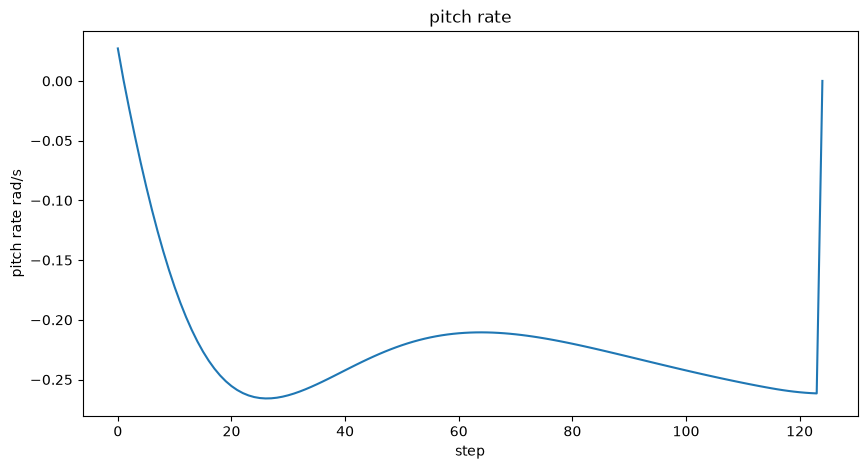

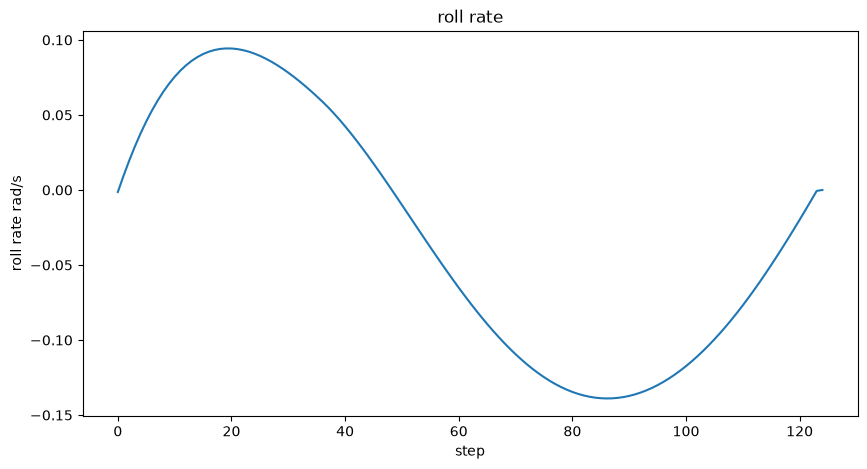

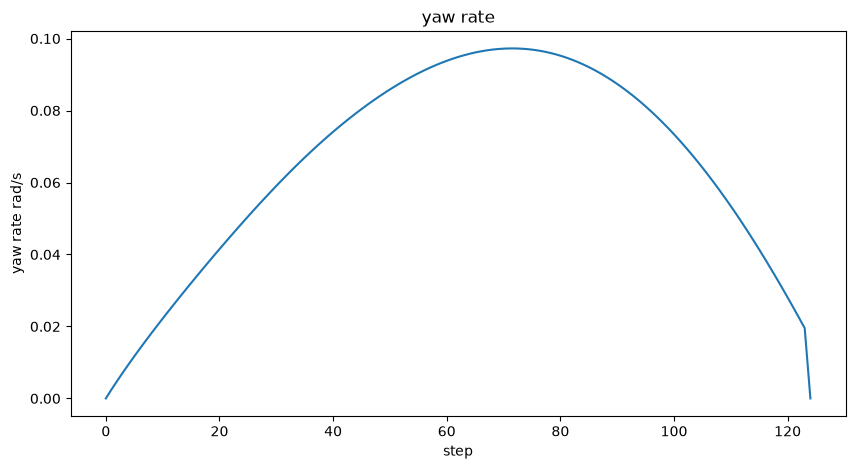

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(pitch_rates)

plt.xlabel("step")
plt.ylabel("pitch rate rad/s")
plt.title("pitch rate")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(roll_rates)

plt.xlabel("step")
plt.ylabel("roll rate rad/s")
plt.title("roll rate")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(yaw_rates)

plt.xlabel("step")
plt.ylabel("yaw rate rad/s")
plt.title("yaw rate")
plt.show()



In [29]:
class FlightEnv(gym.Env):

    def __init__(self):
        super().__init__()

        self.fdm = jsbsim.FGFDMExec(jsbsim.get_default_root_dir())
        self.fdm.load_model("c172p")

        self.action_space = gym.spaces.Box(
            low=-1,
            high=1,
            shape=(4,),
            dtype=np.float32
        )

        self.observation_space = gym.spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(12,), # pitch rate roll rate yaw rate eklendi
            dtype=np.float32
        )

        self.step_count = 0
        self.max_steps = 500

        # target vericez
        self.target_altitude = 5000.0
        self.target_velocity = 120.0
        self.target_heading = 0.0

    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.step_count = 0

        self.target_altitude = self.np_random.uniform(4500.0, 5500.0)
        self.target_velocity = self.np_random.uniform(110.0, 130.0)
        self.target_heading = self.np_random.uniform(-np.pi, np.pi)

        self.fdm = jsbsim.FGFDMExec(jsbsim.get_default_root_dir())

        self.fdm.load_model("c172p")

        self.fdm["ic/h-sl-ft"] = 5000
        self.fdm["ic/vc-kts"] = 120
        self.fdm["ic/terrain-elevation-ft"] = 0

        self.fdm.run_ic()

        observation = self._get_observation()

        info = {}

        return observation, info 


    def _get_observation(self):

        altitude = self.fdm["position/h-sl-ft"]
        velocity = self.fdm["velocities/vtrue-kts"]
        pitch = self.fdm["attitude/theta-rad"]
        roll = self.fdm["attitude/phi-rad"]
        yaw = self.fdm["attitude/psi-rad"]
        vertical_speed = self.fdm["velocities/v-down-fps"]

        pitch_rate = self.fdm["velocities/q-rad_sec"]
        roll_rate = self.fdm["velocities/p-rad_sec"]
        yaw_rate = self.fdm["velocities/r-rad_sec"]

        # artık ppo ya hedef değerlerini de vericez
        altitude_error = self.target_altitude - altitude
        velocity_error = self.target_velocity - velocity
        heading_error = (self.target_heading - yaw + np.pi) % (2 * np.pi) - np.pi # açılar arasındak ifarkı alka için 179 ve -179 arasındaki fark 2 normalde normal çıakrırsak 358 olur

        observation = np.array([
            altitude,
            velocity,
            pitch,
            roll,
            yaw,
            vertical_speed,
            pitch_rate,
            roll_rate,
            yaw_rate,
            altitude_error,
            velocity_error,
            heading_error
        ], dtype=np.float32)


        return observation



    def step(self, action):
        elevator = action[0]
        aileron = action[1]
        rudder = action[2] 
        throttle = (action[3] + 1) / 2

        self.fdm["fcs/elevator-cmd-norm"] = float(elevator)
        self.fdm["fcs/aileron-cmd-norm"] = float(aileron)
        self.fdm["fcs/rudder-cmd-norm"] = float(rudder)
        self.fdm["fcs/throttle-cmd-norm"] = float(throttle)

        self.fdm.run()

        self.step_count += 1
        
        observation = self._get_observation()

        altitude = observation[0]
        velocity = observation[1]
        pitch = observation[2]
        roll = observation[3]
        yaw = observation[4]
        vertical_speed = observation[5]
        roll_rate = observation[6]
        pitch_rate = observation[7]
        yaw_rate = observation[8]

        target_heading = self.target_heading
        target_altitude = self.target_altitude
        target_velocity = self.target_velocity
        target_pitch = 0.0
        target_roll = 0.0

        heading_error = abs(target_heading - yaw + np.pi) % (2 * np.pi) - np.pi
        altitude_error = abs(altitude - target_altitude)
        velocity_error = abs(velocity - target_velocity)
        pitch_error = abs(pitch - target_pitch)
        roll_error = abs(roll - target_roll)
        rate_penalty = (0.1 * abs(pitch_rate) + 0.1 * abs(roll_rate) + 0.05 * abs(yaw_rate))
        

        reward = float(
            -0.001 * altitude_error
            -0.01 * velocity_error
            -1.0 * pitch_error
            -1.0 * roll_error
            -0.5 * heading_error
            -rate_penalty
        )


        terminated = False
        terminated_reason = None

        if altitude <= 0:
            terminated = True
            terminated_reason = "sınırları geçti"

        if abs(pitch) > np.deg2rad(60):
            terminated = True
            terminated_reason = "pitch hatası"

        if abs(roll) > np.deg2rad(80):
            terminated = True
            terminated_reason = "sınırları roll hatası"

        if velocity < 40:
            terminated = True
            terminated_reason = "velocity hatası"

        if terminated:

            reward -=100.0

        truncated = self.step_count > self.max_steps


        info = {
            "altitude" : float(altitude),
            "velocity" : float(velocity),
            "pitch" : float(pitch),
            "roll" : float(roll),
            "termianted reason" : terminated_reason
        }

        return (observation, reward, terminated, truncated, info)



In [30]:
env = FlightEnv()
check_env(env, warn=True)

obs, info = env.reset()
print(obs)



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [31]:
try:
    vec_env.close()
except:
    pass

vec_env = DummyVecEnv([lambda: FlightEnv()])
vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=True)

model = PPO("MlpPolicy", vec_env, verbose=1)

vec_env.training = True
vec_env.norm_reward = True

model.learn(total_timesteps=1000)



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

In [32]:
# vec_env.training = False
# vec_env.norm_reward = False

# obs = vec_env.reset()
# print("-" * 100)
# print("hedef alt, vel ve heading: ", vec_env.get_attr("target_altitude"), vec_env.get_attr("target_velocity"), np.rad2deg(vec_env.get_attr("target_heading")))

# for i in range(500):

#     action, _ = model.predict(obs, deterministic=True)

#     obs, reward, done, info = vec_env.step(action)

#     if done[0]:
#         print("bitti")

#         break

In [33]:
# for episode in range(5):

#     obs = vec_env.reset()
#     print("episode", episode)
#     print("=" * 100)
#     print("hedef alt, vel ve heading: ", vec_env.get_attr("target_altitude"), vec_env.get_attr("target_velocity"), np.rad2deg(vec_env.get_attr("target_heading")))


#     for i in range(500):

#         action, _ = model.predict(obs, deterministic=True)

#         obs, reward, done, info = vec_env.step(action)

#         if done[0]:
#             print("bitti")

#             break

#     real_obs = vec_env.get_original_obs()[0]

#     print("=" * 100)
#     print(f"Son durum:  {real_obs[0]:.1f}, {real_obs[1]:.1f}, {np.rad2deg(real_obs[4]):.1f}")

In [34]:
vec_env.training = True
vec_env.norm_reward = True

model.learn(total_timesteps=100000, reset_num_timesteps=False)



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   

KeyboardInterrupt: 

In [ ]:
# # model.save("/home/senceralishn/pytorch/modelTest")
# from stable_baselines3 import PPO
# model = PPO.load("/home/senceralishn/pytorch/modelTest.zip")

In [28]:
vec_env.training = False
vec_env.norm_reward = False

for episode in range(5):

    obs = vec_env.reset()
    print("episode", episode)
    print("=" * 100)
    print("hedef alt, vel ve heading: ", vec_env.get_attr("target_altitude"), vec_env.get_attr("target_velocity"), np.rad2deg(vec_env.get_attr("target_heading")))


    for i in range(500):

        action, _ = model.predict(obs, deterministic=True)

        obs, reward, done, info = vec_env.step(action)

        if done[0]:
            print("bitti")

            break

    real_obs = vec_env.get_original_obs()[0]

    print("=" * 100)
    print(f"Son durum:  {real_obs[0]:.1f}, {real_obs[1]:.1f}, {np.rad2deg(real_obs[4]):.1f}")



     JSBSim Flight Dynamics Model v1.3.1 May 17 2026 14:26:04
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Reading Aircraft Configuration File: c172
                            Version: 2.0


This aircraft model is a BETA release!!!

This aircraft model probably will not fly as expected.

Use this model for development purposes ONLY!!!

  Description:   Cessna C-172
  Model Author:  Unknown
  Creation Date: 2002-01-01
  Version:       $Id: c172p.xml,v 1.29 2013/10/25 15:32:49 jentron Exp $

  Aircraft Metrics:
    WingArea: 174.000000
    WingSpan: 35.800000
    Incidence: 0.000000
    Chord: 4.900000
    H. Tail Area: 21.900000
    H. Tail Arm: 15.700000
    V. Tail Area: 16.500000
    V. Tail Arm: 0.000000
    Eyepoint (x, y, z): 37.000000 , 0.000000 , 48.000000
    Ref Pt (x, y, z): 43.200000 , 0.000000 , 59.400000
    Visual Ref Pt (x, y, z): 42.600000 , 0.000000 , 38.500000

  Mass and Balance:
    baseIxx: 948.000000 slug-ft2
    baseIyy: 1346.000000 slug-ft2
   